In [1]:
from pathlib import Path
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller

warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 14

In [2]:
# Ensure the project root is on the import path so `src` can be imported.
PROJECT_ROOT = Path.cwd().resolve()
for parent in (PROJECT_ROOT, *PROJECT_ROOT.parents):
    if (parent / 'src').is_dir():
        PROJECT_ROOT = parent
        break
else:
    raise RuntimeError('Run this notebook from inside the StockForecastRisk repository.')

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.forecast_engine.data.loader import RAW_PRICES_PATH, load_raw_prices

raw_prices = load_raw_prices()
raw_prices["date"] = pd.to_datetime(raw_prices["date"])
raw_prices = raw_prices.sort_values(["symbol", "date"]).reset_index(drop=True)

print(f'Loaded {len(raw_prices):,} rows for {raw_prices["symbol"].nunique():,} tickers')
print(f'Source: {RAW_PRICES_PATH}')

display(raw_prices.head())

Loaded 622,731 rows for 502 tickers
Source: D:\StockForecastRisk\data\raw\sp500_yfinance_daily.parquet


,date,symbol,security,gics_sector,gics_sub_industry,adj_close,close,high,low,open,volume
0,2021-07-19,A,Agilent Technologies,Health Care,Life Sciences Tools & Services,142.434052,147.580002,147.970001,146.949997,147.660004,1835100.0
1,2021-07-20,A,Agilent Technologies,Health Care,Life Sciences Tools & Services,144.094101,149.300003,151.250000,147.830002,148.449997,2246000.0
2,2021-07-21,A,Agilent Technologies,Health Care,Life Sciences Tools & Services,143.756302,148.949997,149.910004,147.600006,149.490005,2255700.0
3,2021-07-22,A,Agilent Technologies,Health Care,Life Sciences Tools & Services,145.059174,150.300003,150.500000,148.669998,149.710007,1972800.0
4,2021-07-23,A,Agilent Technologies,Health Care,Life Sciences Tools & Services,146.999084,152.309998,152.410004,150.429993,150.589996,2132000.0


In [3]:
# The handful of tickers the per-symbol charts will show. Pick names with
# different profiles (a mega-cap, a volatile name, a defensive one, an ETF-like
# steady name) so the contrasts are informative.
TICKERS = ["AAPL", "NVDA", "XOM", "JNJ"]

# Fall back to whatever exists if those symbols are not in the data.
available = [ticker for ticker in TICKERS if ticker in set(raw_prices["symbol"])]
if not available:
    available = sorted(raw_prices["symbol"].unique())[:4]
    print(f"Configured tickers not found; using {available} instead.")

subset = raw_prices[raw_prices["symbol"].isin(available)].copy()
print(f"charting: {available}")

charting: ['AAPL', 'NVDA', 'XOM', 'JNJ']


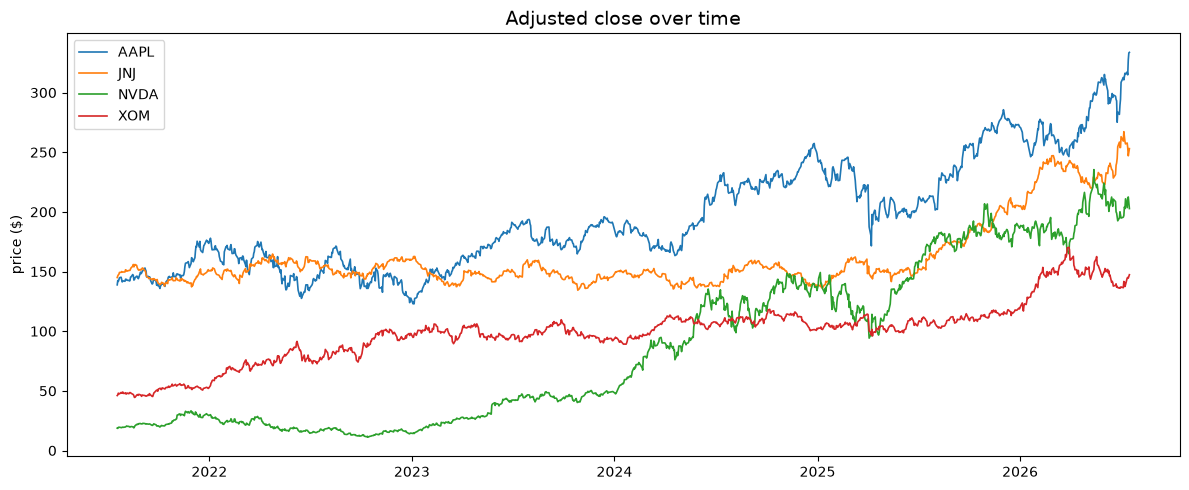

In [4]:
fig, ax = plt.subplots(figsize=(12, 5))
for symbol, group in subset.groupby("symbol"):
    ax.plot(group["date"], group["adj_close"], label=symbol, linewidth=1.2)
ax.set_title("Adjusted close over time")
ax.set_ylabel("price ($)")
ax.legend()
plt.tight_layout()
plt.show()

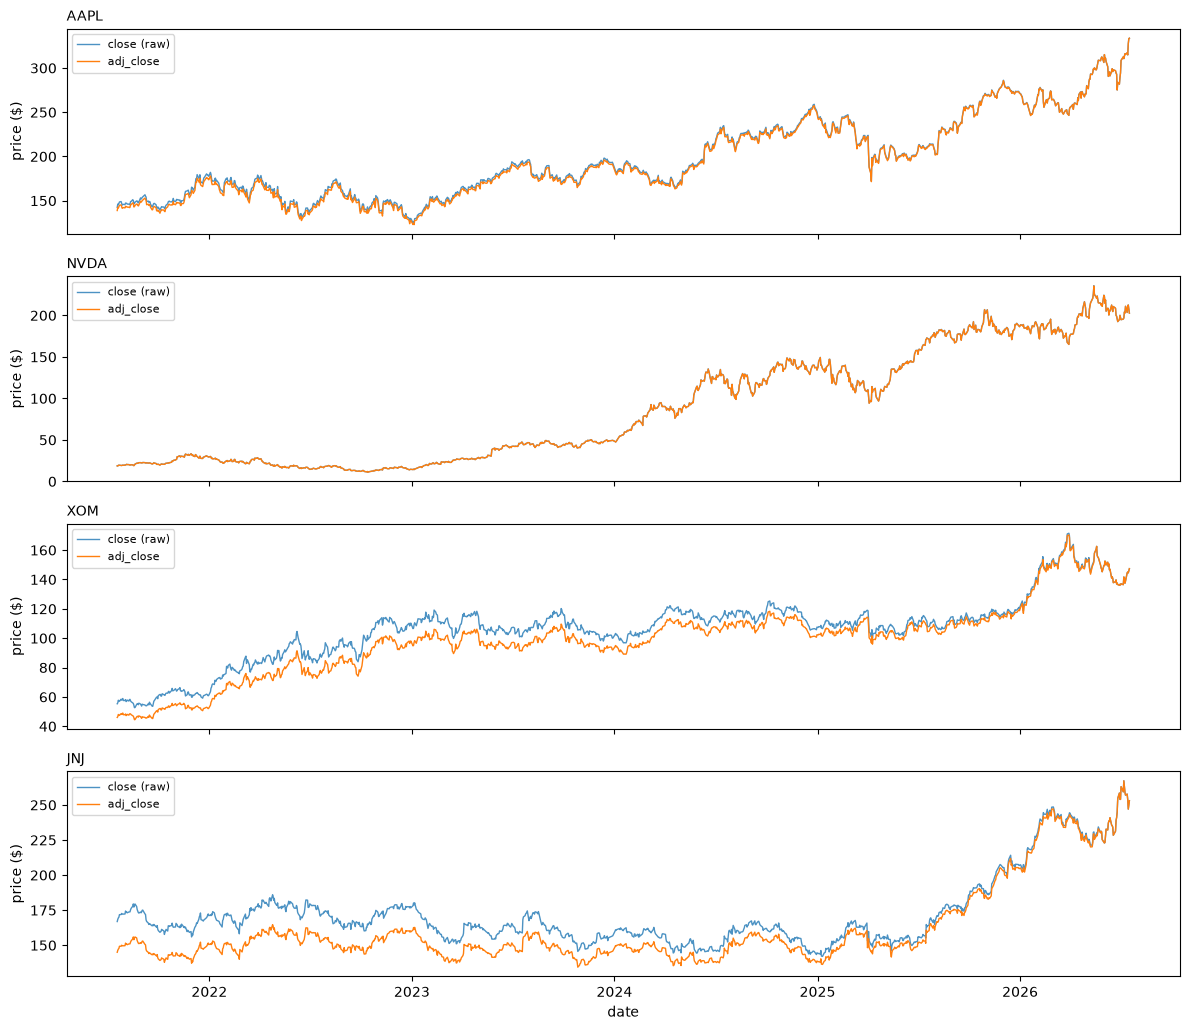

In [5]:
fig, axes = plt.subplots(len(available), 1, figsize=(12, 2.6 * len(available)), sharex=True)
axes = np.atleast_1d(axes)

for ax, symbol in zip(axes, available):
    group = subset[subset["symbol"] == symbol].sort_values("date")
    ax.plot(group["date"], group["close"], label="close (raw)", linewidth=1, alpha=0.8)
    ax.plot(group["date"], group["adj_close"], label="adj_close", linewidth=1)
    ax.set_title(symbol, loc="left", fontsize=10)
    ax.set_ylabel("price ($)")
    ax.legend(fontsize=8)

axes[-1].set_xlabel("date")
plt.tight_layout()
plt.show()

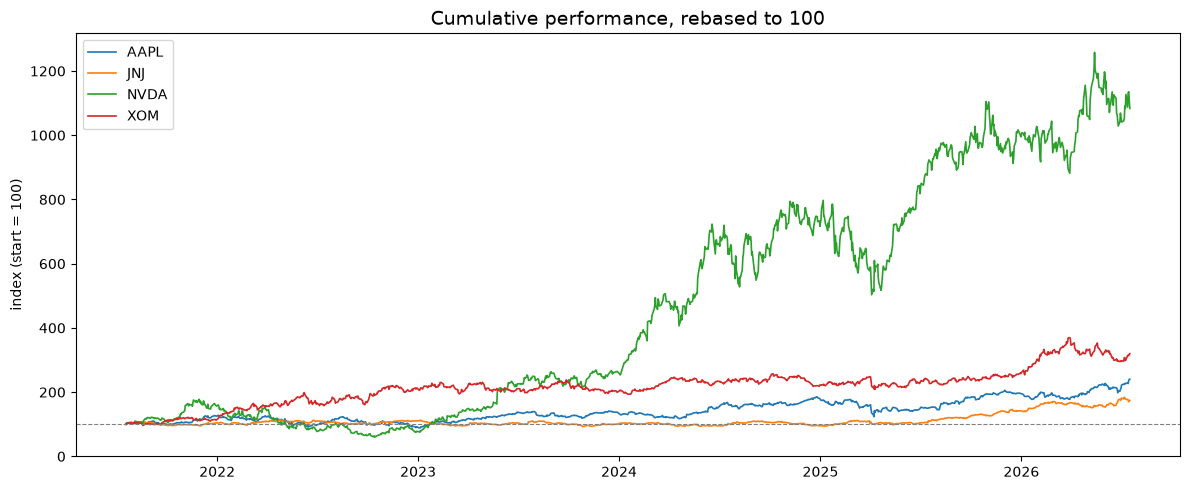

In [6]:
fig, ax = plt.subplots(figsize=(12, 5))
for symbol, group in subset.groupby("symbol"):
    group = group.sort_values("date")
    rebased = group["adj_close"] / group["adj_close"].iloc[0] * 100
    ax.plot(group["date"], rebased, label=symbol, linewidth=1.2)
ax.axhline(100, color="grey", linewidth=0.8, linestyle="--")
ax.set_title("Cumulative performance, rebased to 100")
ax.set_ylabel("index (start = 100)")
ax.legend()
plt.tight_layout()
plt.show()

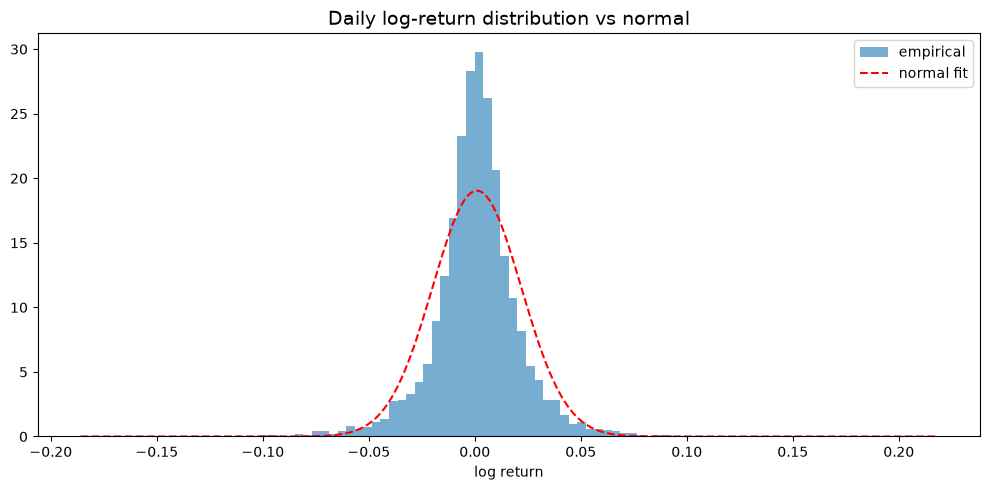

excess kurtosis : 8.37  (0 = normal; higher = fatter tails)
skew            : 0.29


In [7]:
returns = []
for symbol, group in subset.groupby("symbol"):
    group = group.sort_values("date")
    returns.append(np.log(group["adj_close"] / group["adj_close"].shift(1)))
returns = pd.concat(returns).dropna()

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(returns, bins=100, density=True, alpha=0.6, label="empirical")

grid = np.linspace(returns.min(), returns.max(), 300)
normal_pdf = (1 / (returns.std() * np.sqrt(2 * np.pi))) * np.exp(
    -0.5 * ((grid - returns.mean()) / returns.std()) ** 2
)
ax.plot(grid, normal_pdf, "r--", label="normal fit")
ax.set_title("Daily log-return distribution vs normal")
ax.set_xlabel("log return")
ax.legend()
plt.tight_layout()
plt.show()

print(f"excess kurtosis : {returns.kurtosis():.2f}  (0 = normal; higher = fatter tails)")
print(f"skew            : {returns.skew():.2f}")

In [8]:
def adf_pvalue(series):
    """ADF p-value; < 0.05 means reject the unit root -> stationary."""
    clean = pd.Series(series).dropna()
    if len(clean) < 20:
        return np.nan
    try:
        return adfuller(clean, autolag="AIC")[1]
    except Exception:
        return np.nan


# Per-ticker ADF on the selected names, for both price and returns.
records = []
for symbol, group in subset.groupby("symbol"):
    group = group.sort_values("date")
    price = group["adj_close"]
    returns_series = np.log(price / price.shift(1))
    price_p = adf_pvalue(price)
    return_p = adf_pvalue(returns_series)
    records.append({
        "symbol": symbol,
        "price_pvalue": round(price_p, 4),
        "return_pvalue": round(return_p, 4),
        "price_stationary": price_p < 0.05,
        "return_stationary": return_p < 0.05,
    })

adf_table = pd.DataFrame(records)
display(adf_table)

,symbol,price_pvalue,return_pvalue,price_stationary,return_stationary
0,AAPL,0.9705,0.0,False,True
1,JNJ,0.9943,0.0,False,True
2,NVDA,0.9666,0.0,False,True
3,XOM,0.6675,0.0,False,True


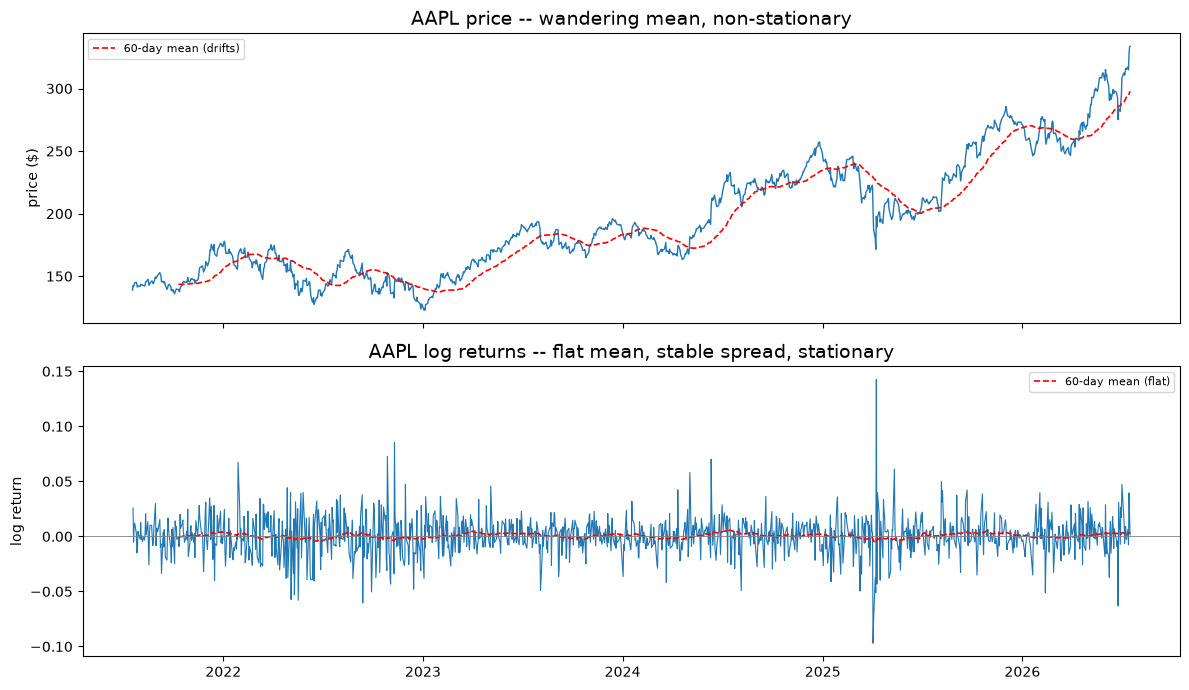

In [9]:
# Visual intuition for the test: price wanders (non-stationary), returns sit on a
# flat mean (stationary). The red rolling-mean line is the tell -- it drifts for
# price and stays flat for returns.
example = available[0]
group = subset[subset["symbol"] == example].sort_values("date")
example_return = np.log(group["adj_close"] / group["adj_close"].shift(1))

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

axes[0].plot(group["date"], group["adj_close"], linewidth=1)
axes[0].plot(group["date"], group["adj_close"].rolling(60).mean(), "r--",
             linewidth=1.2, label="60-day mean (drifts)")
axes[0].set_title(f"{example} price -- wandering mean, non-stationary")
axes[0].set_ylabel("price ($)")
axes[0].legend(fontsize=8)

axes[1].plot(group["date"], example_return, linewidth=0.8)
axes[1].plot(group["date"], example_return.rolling(60).mean(), "r--",
             linewidth=1.2, label="60-day mean (flat)")
axes[1].axhline(0, color="grey", linewidth=0.6)
axes[1].set_title(f"{example} log returns -- flat mean, stable spread, stationary")
axes[1].set_ylabel("log return")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

In [10]:
# Panel-wide summary across ALL symbols (not just the selected few).
panel = []
for symbol, group in raw_prices.groupby("symbol"):
    group = group.sort_values("date")
    price = group["adj_close"]
    returns_series = np.log(price / price.shift(1))
    panel.append({
        "price_stationary": adf_pvalue(price) < 0.05,
        "return_stationary": adf_pvalue(returns_series) < 0.05,
    })

panel = pd.DataFrame(panel)
print(f"tickers tested            : {len(panel)}")
print(f"returns stationary (<5%)  : {panel['return_stationary'].mean() * 100:.1f}% of tickers")
print(f"prices  stationary (<5%)  : {panel['price_stationary'].mean() * 100:.1f}% of tickers")
print("\nExpected: returns ~all stationary, prices ~none -- confirming the choice")
print("to model in return space. Investigate any ticker whose RETURNS are non-stationary.")

tickers tested            : 502
returns stationary (<5%)  : 99.6% of tickers
prices  stationary (<5%)  : 5.4% of tickers

Expected: returns ~all stationary, prices ~none -- confirming the choice
to model in return space. Investigate any ticker whose RETURNS are non-stationary.


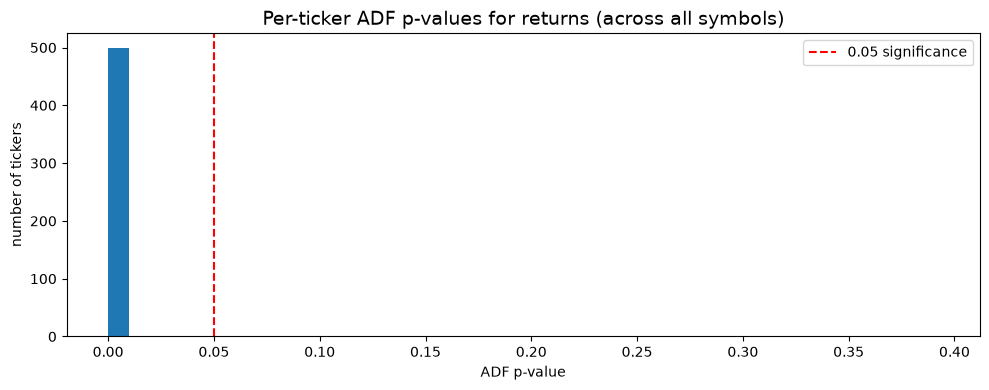

tickers whose returns are NOT stationary at 5%: 2 of 502


In [11]:
# Distribution of per-ticker ADF p-values for RETURNS across the whole panel.
# Near-universal clustering below 0.05 is the panel-level confirmation that
# returns are stationary; any bar to the right of the line is a ticker to inspect.
return_pvalues = []
for symbol, group in raw_prices.groupby("symbol"):
    group = group.sort_values("date")
    return_pvalues.append(adf_pvalue(np.log(group["adj_close"] / group["adj_close"].shift(1))))
return_pvalues = pd.Series(return_pvalues).dropna()

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(return_pvalues, bins=40)
ax.axvline(0.05, color="red", linestyle="--", label="0.05 significance")
ax.set_title("Per-ticker ADF p-values for returns (across all symbols)")
ax.set_xlabel("ADF p-value")
ax.set_ylabel("number of tickers")
ax.legend()
plt.tight_layout()
plt.show()

non_stationary = int((return_pvalues > 0.05).sum())
print(f"tickers whose returns are NOT stationary at 5%: {non_stationary} of {len(return_pvalues)}")

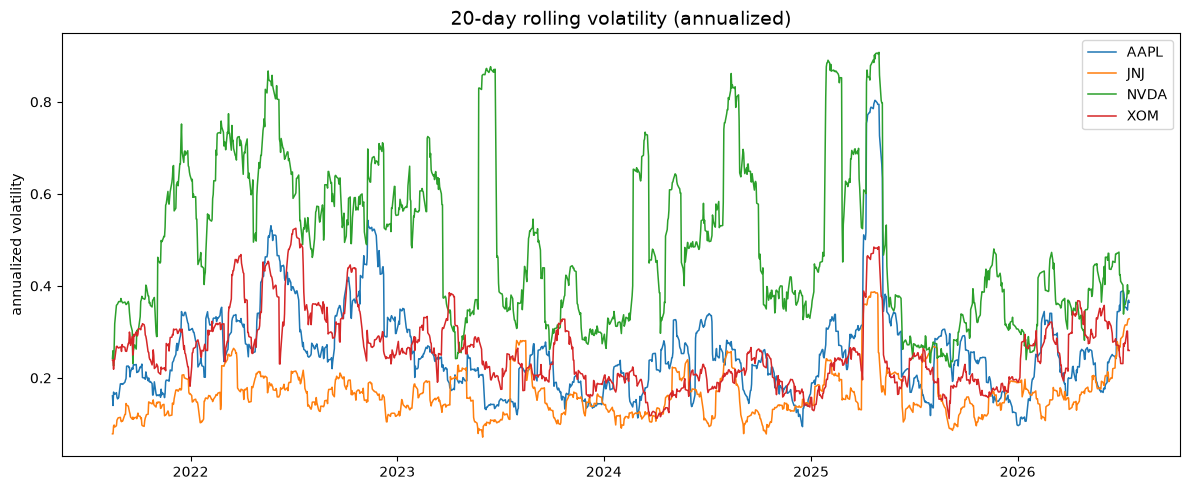

In [12]:
fig, ax = plt.subplots(figsize=(12, 5))
for symbol, group in subset.groupby("symbol"):
    group = group.sort_values("date")
    daily_return = np.log(group["adj_close"] / group["adj_close"].shift(1))
    rolling_vol = daily_return.rolling(20).std() * np.sqrt(252)
    ax.plot(group["date"], rolling_vol, label=symbol, linewidth=1.1)
ax.set_title("20-day rolling volatility (annualized)")
ax.set_ylabel("annualized volatility")
ax.legend()
plt.tight_layout()
plt.show()

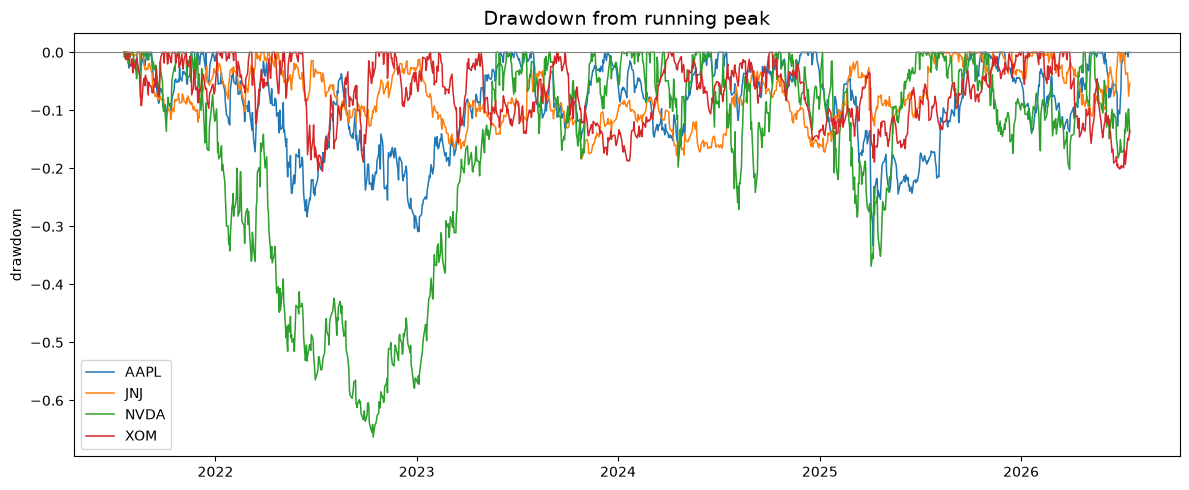

In [13]:
fig, ax = plt.subplots(figsize=(12, 5))
for symbol, group in subset.groupby("symbol"):
    group = group.sort_values("date")
    running_peak = group["adj_close"].cummax()
    drawdown = group["adj_close"] / running_peak - 1
    ax.plot(group["date"], drawdown, label=symbol, linewidth=1.1)
ax.axhline(0, color="grey", linewidth=0.8)
ax.set_title("Drawdown from running peak")
ax.set_ylabel("drawdown")
ax.legend()
plt.tight_layout()
plt.show()

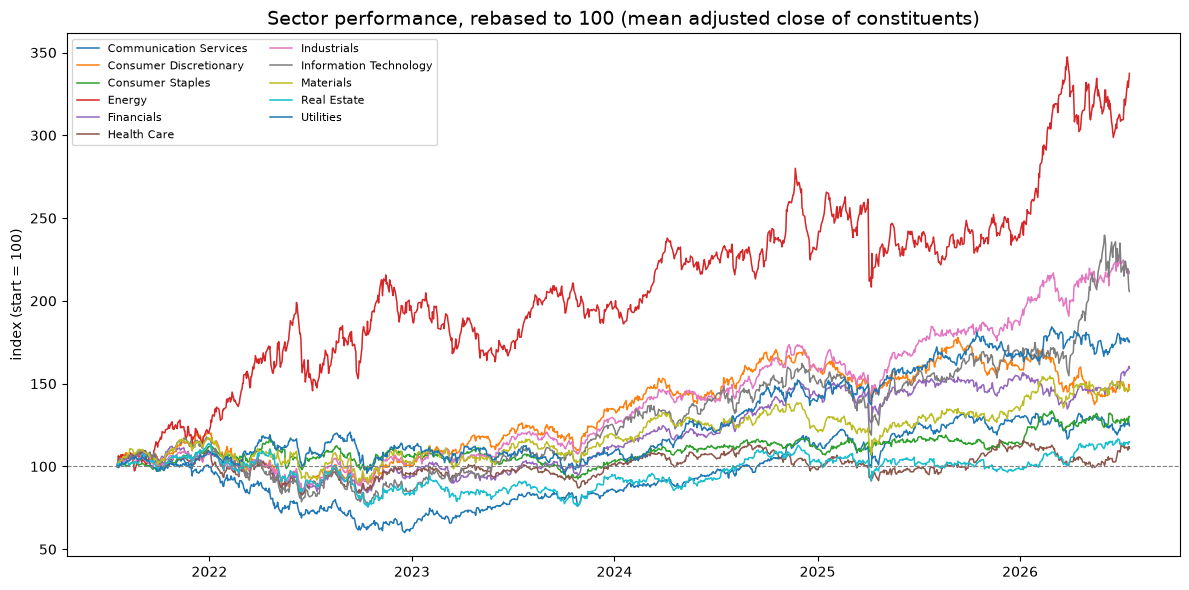

In [14]:
fig, ax = plt.subplots(figsize=(12, 6))
for sector, group in raw_prices.groupby("gics_sector"):
    sector_daily = group.groupby("date")["adj_close"].mean().sort_index()
    rebased = sector_daily / sector_daily.iloc[0] * 100
    ax.plot(rebased.index, rebased, label=sector, linewidth=1.1)
ax.axhline(100, color="grey", linewidth=0.8, linestyle="--")
ax.set_title("Sector performance, rebased to 100 (mean adjusted close of constituents)")
ax.set_ylabel("index (start = 100)")
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()